## Generic Plot (Initial visualisation)

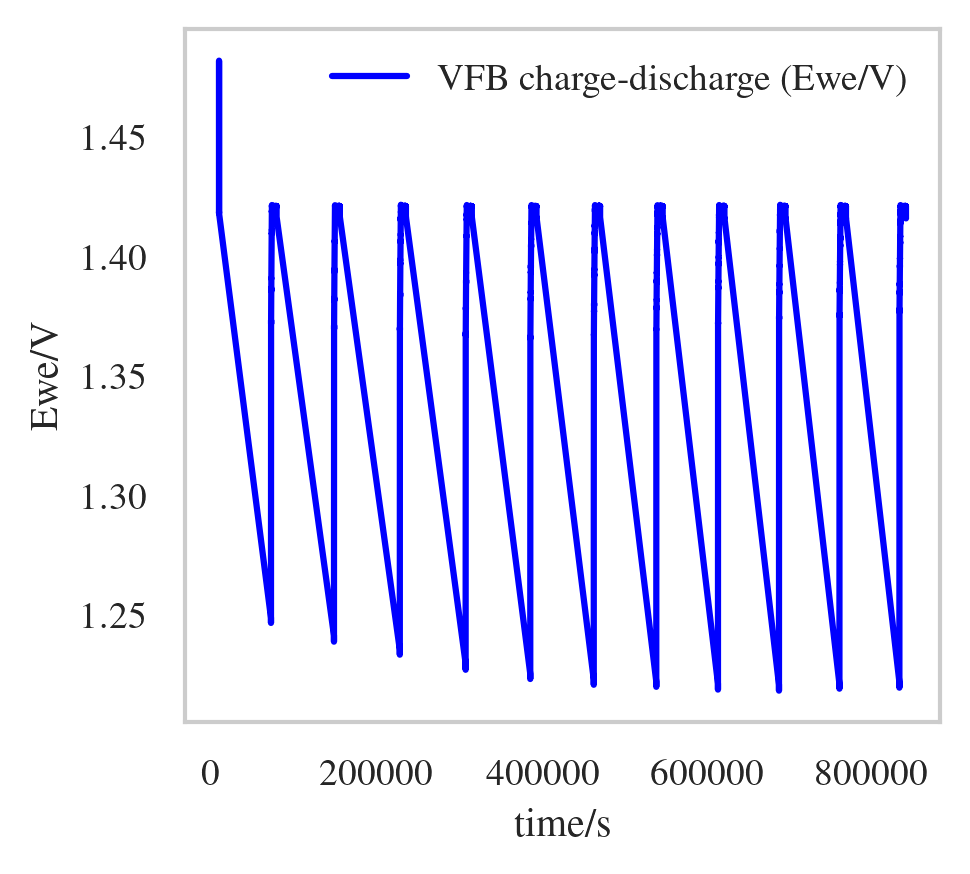

In [1]:
import numpy as np

from redoxed.data_loading.data_loaders import LoaderFactory, BiologicLoader
from redoxed.plots import GenericPlot
from redoxed import config
config.set_latex_mode(True)  


fpath=r"C:\Users\es758\Downloads\1_VFB_22rpm_06_GCPL_C04.mpr"
# fpath=r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.29 FB2_VFB\1_VFB_22rpm_06_GCPL_C04.mpr"
fpath=r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.29 FB2_VFB\1_VFB_22rpm_03_GCPL_C04.mpr"
loader = LoaderFactory.get_loader(fpath)
data = loader.load_data(fpath=fpath)

#data.df.iloc[10:20]

GenericPlot_object = GenericPlot(x_col="time/s", y_col="Ewe/V", y2_col="control/V/mA")
GenericPlot_object = GenericPlot(x_col="time/s", y_col="Ewe/V")
GenericPlot_object.add_plot(data, linestyle = "-", marker = "", color1 = 'blue', color2='red', label = "VFB charge-discharge")
GenericPlot_object.ax.legend()
display(GenericPlot_object.fig)

## Polarisation

,flags,Ns,time/s,dq/mA.h,(Q-Qo)/mA.h,control/V/mA,Ewe/V,I Range,Q charge/discharge/mA.h,half cycle
0,19,0,54814.464065,0.0,0.000000,0.0,0.011835,14,0.0000,0
1,19,0,54815.464065,0.0,0.000000,0.0,0.002022,14,0.0000,0
2,19,0,54816.464065,0.0,0.000000,0.0,0.000456,14,0.0000,0
3,19,0,54817.464065,0.0,0.000000,0.0,0.000265,14,0.0000,0
4,19,0,54818.464065,0.0,0.000000,0.0,0.000131,14,0.0000,0
...,...,...,...,...,...,...,...,...,...,...
10245,19,32,55941.512067,0.0,-0.111356,0.0,-0.004014,14,-3.3381,31
10246,19,32,55942.512067,0.0,-0.111356,0.0,-0.001798,14,-3.3381,31
10247,19,32,55943.512067,0.0,-0.111356,0.0,-0.001664,14,-3.3381,31
10248,19,32,55944.414267,0.0,-0.111356,0.0,-0.001894,14,-3.3381,31


(39, 10)


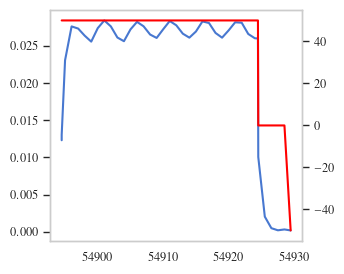

2.7165186 0.0010377836 -5.4152217e-05
[-80. -75. -70. -65. -60. -55. -50. -45. -40. -35. -30. -25. -20. -15.
 -10.  -5.   5.  10.  15.  20.  25.  30.  35.  40.  45.  50.  55.  60.
  65.  70.  75.  80.]


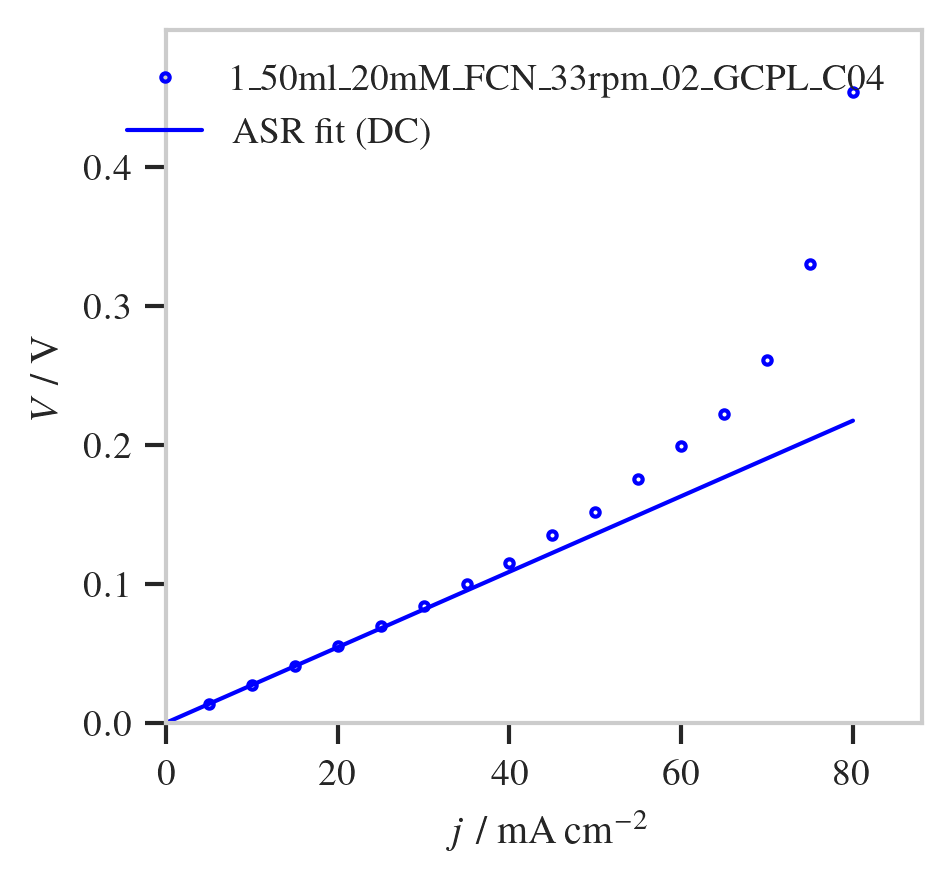

In [2]:
from redoxed.data_loading.data_loaders import LoaderFactory, BiologicLoader, CSVLoader
from redoxed.plots import NyquistPlot, DRTPlot, PolarisationPlot
from redoxed.impedance import EISData, DRTData
from redoxed.dc import PolarisationData
import matplotlib.pyplot as plt
import numpy as np

from redoxed import config
config.set_latex_mode(True)  

### polarisation
fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.05.06 FB2_FCN_KCl_E620K_1186HCB\1_50ml_20mM_FCN_33rpm_02_GCPL_C04.mpr"
ECData_object = BiologicLoader().load_data(fpath=fpath)
display(ECData_object.df)

### Decide range to extract
fig, ax = plt.subplots(1, 1, figsize = (3.25,3), dpi = 100)
ax_I = ax.twinx()

df = ECData_object.df.copy()
df = df.loc[df['half cycle'] == 2]
# df = df.loc[df['half cycle'] >= 24]
# df = df.loc[df['half cycle'] <= 24]
print(df.shape)
ax_I.plot(df['time/s'], df['control/V/mA'], color = 'red')
ax.plot(df['time/s'], df['Ewe/V'])
plt.close(fig)
display(fig)


# ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 2)
PolarisationData_object = ECData_object.to_PolarisationData(A=5, pulse_index_range=(-10,None))

data_plot = PolarisationPlot(figsize=(3.25, 3), dpi=300) 
data_plot.add_plot(PolarisationData_object, linestyle = "", marker = "o", markersize = 2, markerfacecolor = 'none', markeredgecolor = 'blue', color = 'blue')#, label="data")
PolarisationData_object.calculate_ASR(restrict_to_zero=False, j_range=(-10,10))
j_pred = np.sort(PolarisationData_object.j)
V_pred = PolarisationData_object.ASR*j_pred/1000 # account for mA
PolarisationData_object_fit = PolarisationData(j=j_pred, V=V_pred, A=5)
data_plot.add_plot(PolarisationData_object_fit, linestyle = "-", marker = "", linewidth = 1, color = 'blue', label = "ASR fit (DC)")
print(PolarisationData_object.ASR, PolarisationData_object.ASR_error, PolarisationData_object.ASR_intercept)
print(PolarisationData_object_fit.j)


# ### EIS quantities
# j_model = j_pred[j_pred >= 0]
# j_model = np.insert(j_model, 0,0)

# V_pos_comps = []

# # remember series resistance
# # V_pos_comps.append(DRT_object.R_0*5*j_pos/1000)
# for i, R in enumerate(Z_list):
#     #print(R)
#     ASR = R*PolarisationData_object.A
#     V_i_pos = ASR*j_model/1000
#     # V_i_pos = R_EIS_total*5*j_pos/1000
#     V_pos_comps.append(V_i_pos)
#     #labels.append(str(i))

# data_plot.ax.stackplot(j_model, V_pos_comps, labels=labels, alpha = 0.6, colors=color_list)

data_plot.ax.set_xlim([0, None])
data_plot.ax.set_ylim([0, None])

data_plot.ax.legend()
display(data_plot.fig)

## Battery Cycling

In [ ]:
battery_cycling_data_array = [
    # battery_cycling_data(label='original',colour='black',fpath=r"C:\Users\es758\Downloads\1_FB2_10mlV_22rpm_1p8V_06_GCPL_C04 (4).mpr"),
    # battery_cycling_data(label='refresh',colour='black',fpath=r"C:\Users\es758\Downloads\3_FB2_10mlV_22rpm_1p8V10min_06_GCPL_C04.mpr"),
    # battery_cycling_data(label='UT 05/02',colour='red',fpath=r"C:\Users\es758\Downloads\2_FB1_10mlV_24rpm_1p8V_inithold_05_GCPL_C02 (1).mpr"),
    # battery_cycling_data(label='T400 04/29',colour='green',fpath=r"C:\Users\es758\Downloads\1_FB1_20ml_1600mM_V_22rpm_07_GCPL_C02 (1).mpr"), 

    battery_cycling_data(label='long VFB',colour='green',fpath=r"C:\Users\es758\Downloads\1_VFB_22rpm_06_GCPL_C04.mpr"), 
    battery_cycling_data(label='long VFB',colour='red',fpath=r"C:\Users\es758\Downloads\2_VFB_22rpm_elecrepl_06_GCPL_C04 (1).mpr"), 
                             ]




for battery in battery_cycling_data_array:
    #print(battery.EE)
    print(battery.VE)
    pass

fig1, ax1 = battery_cycling_plot(battery_cycling_data_array).plot_efficiency(figsize=(3,3), VE=True,CE=False, j=True, linestyle='none')
ax1.set_ylim(80, 100)
ax1.legend(ncol=2, frameon=False, fontsize=9, columnspacing=1, handletextpad = 1, handlelength = 1 )
display(fig1)

fig2, ax2 = battery_cycling_plot(battery_cycling_data_array).plot_QV(figsize=(3,3), marker = '.',fillstyle='full', linestyle='none', markersize = 2)
display(fig2)

#fig1.savefig(fname = "fig1.svg", bbox_inches='tight', dpi=300)
#fig2.savefig(fname = "fig2.svg", bbox_inches='tight', dpi=300)

In [ ]:
import numpy as np


class CyclingData:
    E_cell: np.ndarray
    I: np.ndarray
    t: np.ndarray
    
    label: str | None

    def __init__(self, Z: np.ndarray, f: np.ndarray, label: str = None) -> None:

        self.Z = Z
        self.f = f
        # Crop to f > 0 and calculate Z_quants
        mask = (self.f > 0) & (self.f <= np.inf)
        self.Z = self.Z[mask]
        self.f = self.f[mask]
        self._calculate_z_quants()

        self.label = label  # Optional label for the data

        self._validate()

    def _calculate_z_quants(self) -> None:
        """
        Calculates the real and imaginary parts of the impedance from the complex impedance data.
        """
        self.Z_re = self.Z.real
        self.Z_im = self.Z.imag
        self.Z_mag = np.abs(self.Z)
        self.Z_phase = np.angle(self.Z)

    def _validate(self) -> None:
        """
        Validates the input data to ensure consistency and correctness.

        Raises:
            ValueError: If Z and f do not have the same shape.
            ValueError: If Z and f are not 1D arrays.
            ValueError: If Z or f arrays are empty.
        """
        if self.Z.shape != self.f.shape:
            raise ValueError("Z and f must have the same shape.")
        if len(self.Z.shape) != 1:
            raise ValueError("Z and f must be 1D arrays.")
        if self.Z.size == 0 or self.f.size == 0:
            raise ValueError("Z and f arrays must not be empty.")
            #     # Check if data arrays are set

        #     if self.Z_re is None or self.Z_im is None or self.f is None:
        #         raise ValueError(
        #             "The Real (Z_re), Imaginary (Z_im) impedance, and frequency (f) arrays must be provided."
        #         )
        #     # Check if frequencies are positive
        #     if jnp.any(self.f <= 0):
        # should probably check Z are complex and maybe even set type
        #         raise ValueError("Frequencies (f) must be strictly positive.")
        #     # Check for NaN or infinite values

    def __repr__(self) -> str:
        """
        Returns a string representation of the EISData object.

        Returns:
            str: String representation of the object.
        """
        return f"EISData(Z={self.Z}, f={self.f})"

    def crop_frequency(self, f_min: float, f_max: float) -> None:
        """
        Crops the frequency range of the data to the specified range.

        Args:
            f_min (float): Minimum frequency to retain.
            f_max (float): Maximum frequency to retain.
        """
        mask = (self.f >= f_min) & (self.f <= f_max)
        self.Z = self.Z[mask]
        self.f = self.f[mask]
        self._calculate_z_quants()

    def trim_inductive(self) -> None:
        """
        Trims the inductive part of the data where the imaginary part of the impedance is negative.
        """
        mask = self.Z_im < 0
        self.Z = self.Z[mask]
        self.f = self.f[mask]
        self._calculate_z_quants()

    def estimate_real_intercept(self) -> float:
        """
        Estimates the real intercept of the data by identifying the highest frequency
        points straddling the real axis and performing linear interpolation.

        Returns:
            float: The estimated real intercept (Z_re) where Z_im = 0.

        Raises:
            ValueError: If there are not enough points to perform the interpolation.
        """
        # Find indices where Z_im changes sign
        sign_changes = np.where(np.diff(np.sign(self.Z_im)) != 0)[0]

        if len(sign_changes) == 0:
            raise ValueError("No points straddle the real axis (Z_im = 0).")

        # Determine the indices of the two points for interpolation
        if self.f[0] < self.f[1]:  # Low to high frequency
            idx1 = sign_changes[-1]  # Last sign change
            idx2 = idx1 + 1
        elif self.f[0] > self.f[1]:  # High to low frequency
            idx1 = sign_changes[0]  # First sign change
            idx2 = idx1 + 1

        # Get the real and imaginary parts of the two points
        Z_re1, Z_im1 = self.Z_re[idx1], self.Z_im[idx1]
        Z_re2, Z_im2 = self.Z_re[idx2], self.Z_im[idx2]

        # Perform linear interpolation to find the real intercept (Z_im = 0)
        Z_re_intercept = Z_re1 - (Z_im1 * (Z_re2 - Z_re1)) / (Z_im2 - Z_im1)

        return Z_re_intercept
